##  EDA for CNN/DailyMail 
- Dataset overview
- Text length analysis
- Distribution plots
- Word frequency analysis
- Summary vs article relationship
- Sample visualization
- Insights

### `imports`

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


### `load data`

In [6]:
from datasets import load_dataset

dataset = load_dataset("cnn_dailymail", "3.0.0")

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 287113
    })
    validation: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 13368
    })
    test: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 11490
    })
})


### `ispect data`

In [7]:
sample = dataset["train"][0]

print("ARTICLE:\n", sample["article"])
print("\nSUMMARY:\n", sample["highlights"])

ARTICLE:
 LONDON, England (Reuters) -- Harry Potter star Daniel Radcliffe gains access to a reported £20 million ($41.1 million) fortune as he turns 18 on Monday, but he insists the money won't cast a spell on him. Daniel Radcliffe as Harry Potter in "Harry Potter and the Order of the Phoenix" To the disappointment of gossip columnists around the world, the young actor says he has no plans to fritter his cash away on fast cars, drink and celebrity parties. "I don't plan to be one of those people who, as soon as they turn 18, suddenly buy themselves a massive sports car collection or something similar," he told an Australian interviewer earlier this month. "I don't think I'll be particularly extravagant. "The things I like buying are things that cost about 10 pounds -- books and CDs and DVDs." At 18, Radcliffe will be able to gamble in a casino, buy a drink in a pub or see the horror film "Hostel: Part II," currently six places below his number one movie on the UK box office chart. Deta

### `convert to dataframe`

In [8]:
df = pd.DataFrame(dataset["train"])  

print("Shape:", df.shape)
print("\nColumns:", df.columns)

Shape: (287113, 3)

Columns: Index(['article', 'highlights', 'id'], dtype='object')


In [9]:
df.head()

,article,highlights,id
0,"LONDON, England (Reuters) -- Harry Potter star...",Harry Potter star Daniel Radcliffe gets £20M f...,42c027e4ff9730fbb3de84c1af0d2c506e41c3e4
1,Editor's note: In our Behind the Scenes series...,Mentally ill inmates in Miami are housed on th...,ee8871b15c50d0db17b0179a6d2beab35065f1e9
2,"MINNEAPOLIS, Minnesota (CNN) -- Drivers who we...","NEW: ""I thought I was going to die,"" driver sa...",06352019a19ae31e527f37f7571c6dd7f0c5da37
3,WASHINGTON (CNN) -- Doctors removed five small...,"Five small polyps found during procedure; ""non...",24521a2abb2e1f5e34e6824e0f9e56904a2b0e88
4,(CNN) -- The National Football League has ind...,"NEW: NFL chief, Atlanta Falcons owner critical...",7fe70cc8b12fab2d0a258fababf7d9c6b5e1262a


### `Text Length Analysis`

In [10]:
df["article_len"] = df["article"].apply(lambda x: len(x.split()))
df["summary_len"] = df["highlights"].apply(lambda x: len(x.split()))

In [11]:
df[["article_len", "summary_len"]].describe().T

,count,mean,std,min,25%,50%,75%,max
article_len,287113.0,691.870326,336.500292,8.0,443.0,632.0,877.0,2347.0
summary_len,287113.0,51.574101,21.256336,4.0,38.0,48.0,60.0,1296.0


- average article length is 337 word
- average summary length is 21 word

- `histograms`

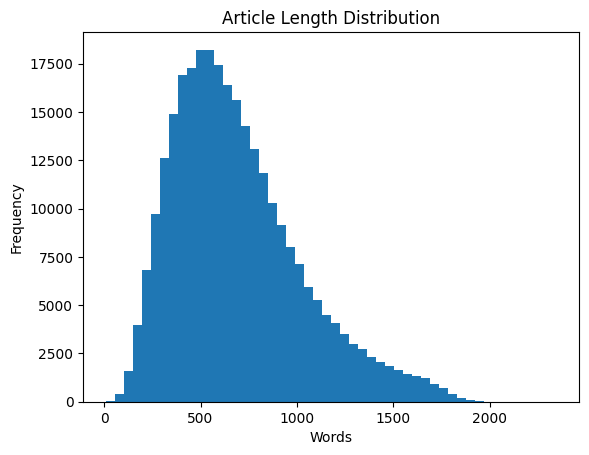

In [12]:
plt.figure()
plt.hist(df["article_len"], bins=50)
plt.title("Article Length Distribution")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

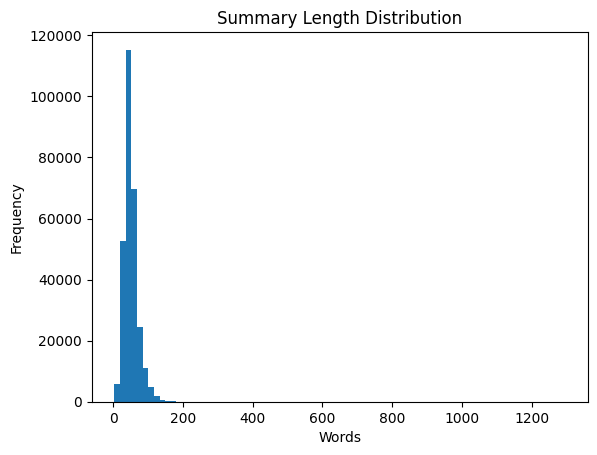

In [13]:
plt.figure()
plt.hist(df["summary_len"], bins=80)
plt.title("Summary Length Distribution")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

- `max length`

In [14]:
print("Max article length:", df["article_len"].max())
print("Max summary length:", df["summary_len"].max())

Max article length: 2347
Max summary length: 1296


In [15]:
np.percentile(df["article_len"], [50, 75, 90, 95, 99])

array([ 632.,  877., 1166., 1363., 1674.])

- helps later when choosing max input length for transformer

- `Boxplot for outlier detection`

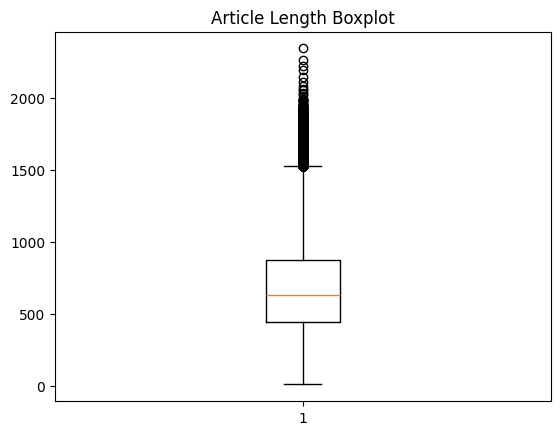

In [16]:
plt.figure()
plt.boxplot(df["article_len"])
plt.title("Article Length Boxplot")
plt.show()

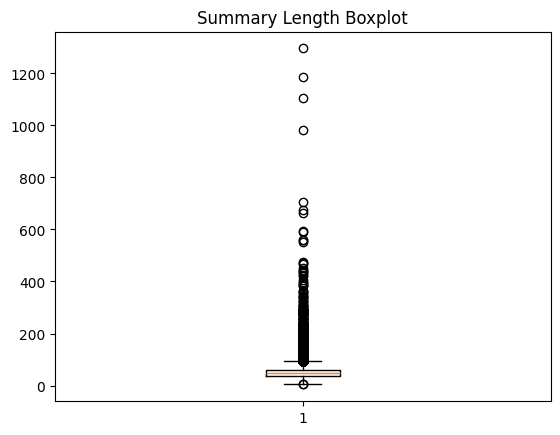

In [17]:
plt.figure()
plt.boxplot(df["summary_len"])
plt.title("Summary Length Boxplot")
plt.show()

In [18]:
# outliers in article length usin IQR
Q1 = df["article_len"].quantile(0.25)
Q3 = df["article_len"].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df["article_len"] < Q1 - 1.5 * IQR) | (df["article_len"] > Q3 + 1.5 * IQR)]
print("Number of outliers in article length:", len(outliers))
# its percentage of total
print("Percentage of outliers in article length:", len(outliers) / len(df) * 100)
# outliers below lower bound
outliers_below = df[df["article_len"] < Q1 - 1.5 * IQR]
print("Number of outliers below lower bound:", len(outliers_below))


Number of outliers in article length: 7183
Percentage of outliers in article length: 2.501802426222428
Number of outliers below lower bound: 0


- no need to remove, as all of them are above upper bound (isnt a big issue for articles)

In [19]:
# outliers in summary length usin IQR
Q1 = df["summary_len"].quantile(0.25)
Q3 = df["summary_len"].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df["summary_len"] < Q1 - 1.5 * IQR) | (df["summary_len"] > Q3 + 1.5 * IQR)]
print("Number of outliers in summary length:", len(outliers))
# its percentage of total
print("Percentage of outliers in summary length:", len(outliers) / len(df) * 100)
# outliers above upper bound
outliers_above = df[df["summary_len"] > Q3 + 1.5 * IQR]
print("Number of outliers above upper bound:", len(outliers_above))


Number of outliers in summary length: 11843
Percentage of outliers in summary length: 4.124856763713241
Number of outliers above upper bound: 11841


- all outliers in summary lenth are above upper bound, which can be an issue(improper summarization)

### `most common words`

In [20]:
from collections import Counter
import re

def tokenize(text):
    text = text.lower()
    words = re.findall(r'\b\w+\b', text)
    return words

all_words = []

for text in df["article"][:5000]: 
    all_words.extend(tokenize(text))

word_counts = Counter(all_words)

In [21]:
common_words = word_counts.most_common(20)
common_words

[('the', 184330),
 ('to', 83626),
 ('of', 76372),
 ('a', 75867),
 ('and', 74547),
 ('in', 66166),
 ('s', 42783),
 ('that', 34574),
 ('said', 31933),
 ('for', 28219),
 ('is', 26762),
 ('it', 24401),
 ('was', 24346),
 ('on', 24049),
 ('he', 23867),
 ('with', 20134),
 ('i', 18177),
 ('as', 16422),
 ('at', 15269),
 ('his', 14873)]

- most common words are all stop words
- For Transformer-based models: Don't remove stop words

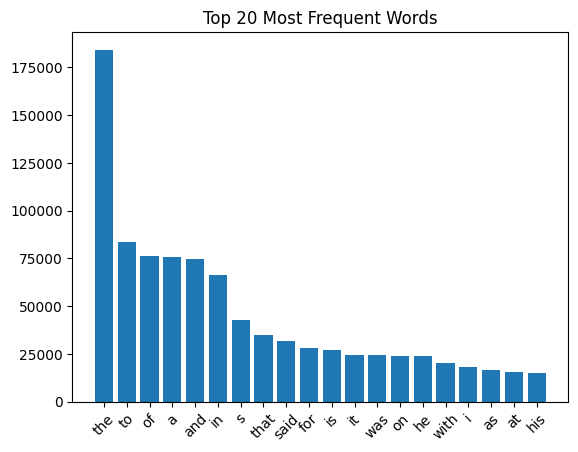

In [22]:
words, counts = zip(*common_words)

plt.figure()
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 20 Most Frequent Words")
plt.show()

### `Summary vs Article Relationship`

- `Correlation`

In [23]:
df[["article_len", "summary_len"]].corr()

,article_len,summary_len
article_len,1.000000,0.293098
summary_len,0.293098,1.000000


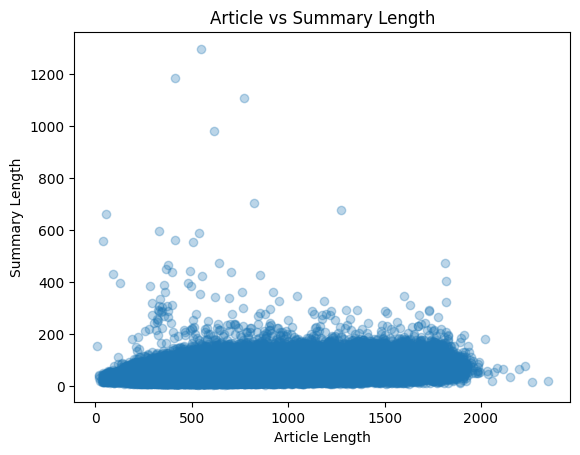

In [24]:
plt.figure()
plt.scatter(df["article_len"], df["summary_len"], alpha=0.3)
plt.xlabel("Article Length")
plt.ylabel("Summary Length")
plt.title("Article vs Summary Length")
plt.show()

- Most summaries are concentrated between 50–200 words, regardless of article length.
- most of summaries are length-controlled , not proportional to input size.
- to avoid chuncking, its better to remove lomg summaries 

- `Length ratio`

In [25]:
df["compression_ratio"] = df["summary_len"] / df["article_len"] 

df["compression_ratio"].describe()

count    287113.000000
mean          0.090875
std           0.074306
min           0.004639
25%           0.054795
50%           0.078341
75%           0.112717
max          19.000000
Name: compression_ratio, dtype: float64

- in average summary length is 9% of article length

In [26]:
# put compression ratios into bins then arrange descending
discrete_bins = [0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
df["compression_bin"] = pd.cut(df["compression_ratio"], bins=discrete_bins)
bin_counts = df["compression_bin"].value_counts().sort_index()
bin_counts

compression_bin
(0.0, 0.01]       161
(0.01, 0.02]     2023
(0.02, 0.03]     8362
(0.03, 0.04]    19133
(0.04, 0.05]    27464
(0.05, 0.06]    31099
(0.06, 0.07]    31301
(0.07, 0.08]    28551
(0.08, 0.09]    24845
(0.09, 0.1]     21115
(0.1, 0.11]     17141
(0.11, 0.12]    14426
(0.12, 0.13]    11757
(0.13, 0.14]     9436
(0.14, 0.15]     7764
(0.15, 0.16]     6256
(0.16, 0.17]     5067
(0.17, 0.18]     4059
(0.18, 0.19]     3179
(0.19, 0.2]      2713
(0.2, 0.25]      7123
(0.25, 0.3]      2522
(0.3, 0.35]       820
(0.35, 0.4]       354
(0.4, 0.45]       163
(0.45, 0.5]        72
(0.5, 0.6]         44
(0.6, 0.7]         19
(0.7, 0.8]         81
(0.8, 0.9]         26
(0.9, 1.0]         11
Name: count, dtype: int64

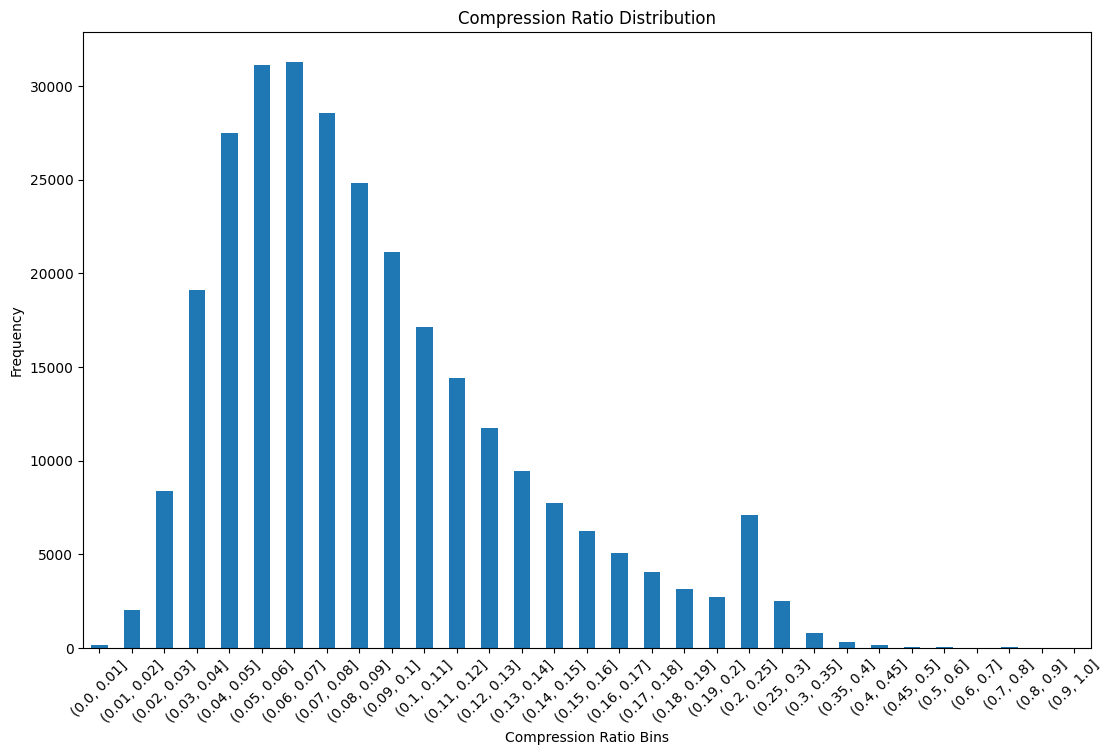

In [27]:
plt.figure(figsize=(13, 8))
bin_counts.plot(kind="bar")
plt.xticks(rotation=45)
plt.title("Compression Ratio Distribution")
plt.xlabel("Compression Ratio Bins")
plt.ylabel("Frequency")
plt.show()

- Compression ratio distribution is skewed towards very low values, most summaries are less than 10% the length of the original article.
- high compression ratios (0.5-1), indace improper summarization (outliers) -> can remove later 

### `Data Quality Checks`

- `Missing values`

In [28]:
df[['article', 'highlights']].isnull().sum()

article       0
highlights    0
dtype: int64

- `empty text`

In [29]:
df[df["article"].str.strip() == ""]

,article,highlights,id,article_len,summary_len,compression_ratio,compression_bin


- no empty or misssing values 

In [30]:
## articles with short lengths and high compression ratios
short_articles = df[(df["article_len"] < 50) & (df["compression_ratio"] > 0.4)]
short_articles[["article", "highlights", "article_len", "summary_len", "compression_ratio"]]

,article,highlights,article_len,summary_len,compression_ratio
1511,(CNN) -- The U.S. Commission on International ...,"U.S. panel reports examples of intimidation, v...",37,38,1.027027
1706,Congressman Jared Polis . (D) Colorado: Distri...,Two freshman representatives document their ex...,18,31,1.722222
2902,Congressman Jared Polis . (D) Colorado: Distri...,Video: Hand-held cams track freshmen moves .\n...,18,38,2.111111
5390,(CNN) -- One of Africa's brightest young write...,31-year-old novelist grew up in Nigeria and st...,43,37,0.860465
5788,(CNN) -- Watch more from Talk Asia's interview...,Exclusive online only extra footage from Talk ...,47,46,0.978723
6353,(CNN) -- CNN explores Beijing's underground mu...,Buyi is one of the bands breaking through the ...,21,41,1.952381
12489,(CNN) -- The 39-year-old Liberian artist was e...,Artist had to leave Liberia during civil war; ...,42,41,0.976190
34825,"World-renowned chef, author and Emmy winning t...",A tour of Morocco .\n10 things you may not hav...,37,15,0.405405
36802,"World-renowned chef, author and Emmy winning t...",Which American food is a hit in Libya?\nBourda...,36,21,0.583333
36926,"World-renowned chef, author and Emmy winning t...",11 things to know about Quebec .\nO Canada! Ou...,36,15,0.416667


In [31]:
# count of short articles
len(short_articles)

26

- short articles with insufficient summarization -> better remove

In [32]:
## summary with short lengths and high compression ratios
short_summaries = df[(df["summary_len"] > 300) & (df["compression_ratio"] > 0.40)]
short_summaries[["article", "highlights", "article_len", "summary_len", "compression_ratio"]]

,article,highlights,article_len,summary_len,compression_ratio
99337,"By . Nick Enoch . PUBLISHED: . 11:00 EST, 9 Ma...","Keith Turner, 43, given 16-month prison senten...",691,340,0.492041
111937,"By . Toni Jones . PUBLISHED: . 09:29 EST, 16 O...",The Great British Bake Off final expects to dr...,550,1296,2.356364
119897,"By . Damien Gayle . PUBLISHED: . 07:45 EST, 26...",Mobile devices have changed the way that offic...,365,450,1.232877
120949,"By . Tracey Cox . PUBLISHED: . 02:11 EST, 15 M...",Cox blames Facebook and Twitter for 'emotional...,480,395,0.822917
126210,By . Sophie Borland and Daniel Martin . PUBLIS...,11 of the 14 hospital trusts investigated put ...,1273,675,0.530244
131272,"By . Lizzie Edmonds . PUBLISHED: . 05:04 EST, ...",Centers for Disease Control and Prevention rep...,544,355,0.652574
170075,By . David Kent . As the 2014 World Cup contin...,Spain take on Chile in both sides' second Grou...,335,335,1.000000
171936,"By . Matt Chorley, Mailonline Political Editor...",Labour government did deal with Sinn Fein as p...,771,1106,1.434501
176673,By . Charlie Scott . Follow @@charliefscott . ...,Hosts Brazil welcome captain Thiago Silva back...,495,386,0.779798
183358,By . Simeon Gholam . Follow @@SimGholam . Cham...,Real Madrid take on Spanish rivals Sevilla in ...,285,384,1.347368


In [33]:
len(short_summaries)

37

## Cleaning + Preprocessing

In [34]:
df.columns

Index(['article', 'highlights', 'id', 'article_len', 'summary_len',
       'compression_ratio', 'compression_bin'],
      dtype='object')

In [35]:
df2 = df[["article", "highlights", "article_len", "summary_len", "compression_ratio"]] 
df2.head()

,article,highlights,article_len,summary_len,compression_ratio
0,"LONDON, England (Reuters) -- Harry Potter star...",Harry Potter star Daniel Radcliffe gets £20M f...,455,41,0.090110
1,Editor's note: In our Behind the Scenes series...,Mentally ill inmates in Miami are housed on th...,698,49,0.070201
2,"MINNEAPOLIS, Minnesota (CNN) -- Drivers who we...","NEW: ""I thought I was going to die,"" driver sa...",743,43,0.057873
3,WASHINGTON (CNN) -- Doctors removed five small...,"Five small polyps found during procedure; ""non...",414,27,0.065217
4,(CNN) -- The National Football League has ind...,"NEW: NFL chief, Atlanta Falcons owner critical...",973,44,0.045221


### `Text Cleaning`

In [36]:
def clean_text(text):
    text = re.sub(r"\s+", " ", text)   # remove extra spaces
    text = text.strip()
    return text

df2["article"] = df2["article"].apply(clean_text)
df2["highlights"] = df2["highlights"].apply(clean_text)

C:\Users\laphouse\AppData\Local\Temp\ipykernel_22696\4162589498.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2["article"] = df2["article"].apply(clean_text)
C:\Users\laphouse\AppData\Local\Temp\ipykernel_22696\4162589498.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2["highlights"] = df2["highlights"].apply(clean_text)


### `Remove duplicates`


In [37]:
len(df2)

287113

In [38]:
df2.drop_duplicates(subset=["article"], inplace=True)

C:\Users\laphouse\AppData\Local\Temp\ipykernel_22696\1953515481.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2.drop_duplicates(subset=["article"], inplace=True)


In [39]:
len(df2)

284003

### `Remove short articles with high compression ratio`

In [40]:
df2 = df2[(df2["article_len"] > 50) & (df2["compression_ratio"] < 0.35)]

In [41]:
len(df2)

283212

### `remove long summaries with high compression ratio`

In [42]:
df2 = df2[(df2["summary_len"] < 300) & (df2["compression_ratio"] < 0.35)]

In [43]:
len(df2)

283204

### `Final df`

In [44]:
print("Final shape:", df2.shape)

Final shape: (283204, 5)


In [45]:
df2[["article_len", "summary_len"]].describe().T

,count,mean,std,min,25%,50%,75%,max
article_len,283204.0,693.696759,335.837133,52.0,445.0,633.0,878.0,2347.0
summary_len,283204.0,51.544953,20.281184,4.0,38.0,49.0,60.0,297.0


### `save clean dataset`

In [47]:
df2.to_csv("../Datasets/clean_news_dataset.csv", index=False)

#### `Preprocessing Summary`
- Removed duplicate articles to avoid training bias.
- Cleaned text by normalizing whitespace and formatting.
- Filtered out extremely short articles that do not contain sufficient information.
- Removed abnormal summaries with excessive length.
- Applied compression ratio filtering to ensure meaningful summarization relationships.
- Preserved punctuation and stopwords to maintain natural language structure for transformer models.

`important Decision:`
Unlike traditional NLP pipelines, aggressive preprocessing (such as stopword removal or stemming) was avoided to preserve linguistic structure, which is critical for generative transformer models.


`note` 
- No need for stemming, lemmatization, stopword removal
- Because:
we are doing text generation, not classification

-----

## Next step: `Tokenization` 